In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

In [2]:
    # Function representing dy/dt
    def f(t, y):
        return -1000*y + 3000 - 2000*np.exp(-t)

In [3]:
def euler(h):
    t_start, t_end = 0, 30
    num_steps = int((t_end - t_start) / h)

    t_values = np.linspace(t_start, t_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    
    # Initial condition
    y_values[0] = 0 # y(0) = 0

    
    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(t_values[i], y_values[i])
        
    plt.plot(t_values, y_values, label=f'h={h}')
    
    
    return t_values, y_values

In [4]:
def exact_solution(t):
    return (3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t))

<ipython-input-2-4fe752fa6fbd>:3: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000*np.exp(-t)
<ipython-input-3-e4ca282131ed>:14: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i + 1] = y_values[i] + h * f(t_values[i], y_values[i])


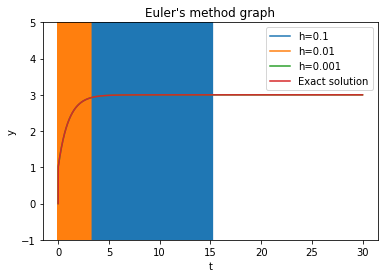

In [5]:
euler(0.1)
euler(0.01)
euler(0.001)
t_values = np.linspace(0, 30, 30000)
y_values = exact_solution(t_values)
plt.plot(t_values, y_values, label=f'Exact solution')

plt.legend()
plt.xlabel('t')
plt.ylabel('y')
plt.title('Euler\'s method graph')
plt.ylim(-1, 5)
plt.show()

This is obviously not working right. I suppose this is a point to show that Euler's forward is not good for a function like this?

In [6]:
def backward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0    
    
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]       
        
        # Implicit function to solve for y_next
        g = lambda y_next: y_next - y_prev - h * f(t_next, y_next)
        # Use previous value as initial guess
        y_values[i] = fsolve(g, y_prev)      
        
    return t_values, y_values

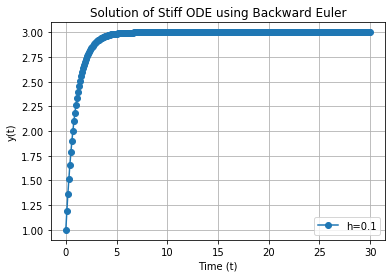

/opt/conda/lib/python3.8/site-packages/scipy/optimize/minpack.py:162: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


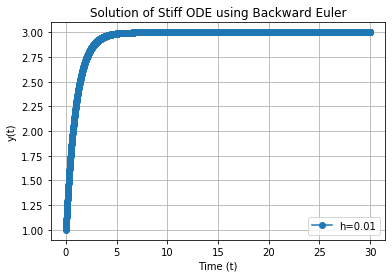

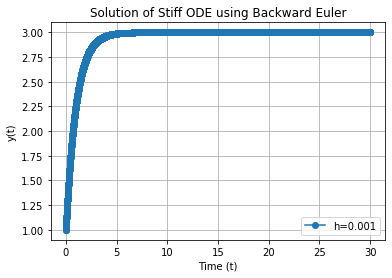

In [7]:
# Parameters
y0 = 1
t0 = 0
tf = 30
h_list = [0.1, 0.01, 0.001]

# Solve the ODE
for i in range(len(h_list)):
    t_values, y_values = backward_euler(f, y0, t0, tf, h_list[i])

    # Plot the results
    plt.plot(t_values, y_values, 'o-', label=f'h={h_list[i]}')
    plt.xlabel('Time (t)')
    plt.ylabel('y(t)')
    plt.title('Solution of Stiff ODE using Backward Euler')
    plt.legend()
    plt.grid(True)
    plt.show()

Backwards euler's method seems to work pretty well for much lower h sizes. This is because the algorithm is unconditionally stable, and the exponentially growth at the beginning is accounted for because of said stability.

In [8]:
# Nonlinear ODE example
def f_nonlinear(t, y):
    return y**2 - 2

In [9]:
def newton_raphson(g, dg, x0, tol=1e-6, max_iter=50):
    x = x0


    for i in range(max_iter):
        x_new = x - g(x) / dg(x)

        if abs(x_new - x) < tol:
            return x_new, i + 1
        x = x_new
    return None, max_iter

In [10]:
# Backward Euler with Newton-Raphson
def backward_euler_newton(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0

    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]

        # Define g for Newton-Raphson
        g = lambda y_next: y_next - y_prev - h * f(t_next, y_next)
        dg = lambda y_next: 1 - 2*h*y_next

        y_next, iterations = newton_raphson(g, dg, y_prev)
        y_values[i] = y_next

    return t_values, y_values

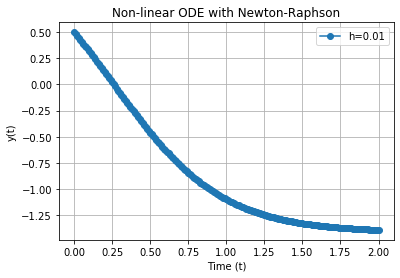

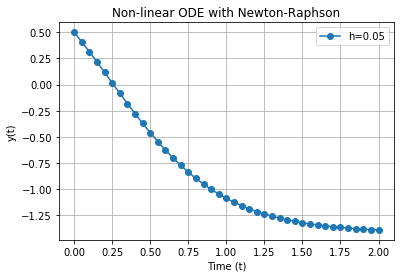

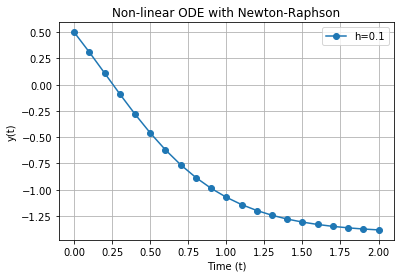

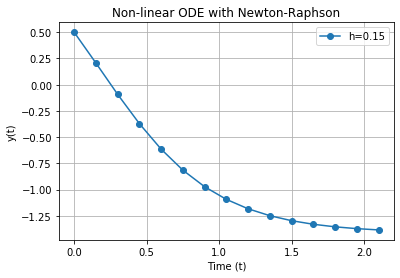

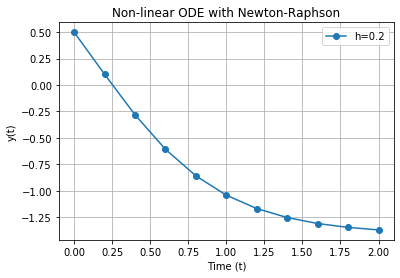

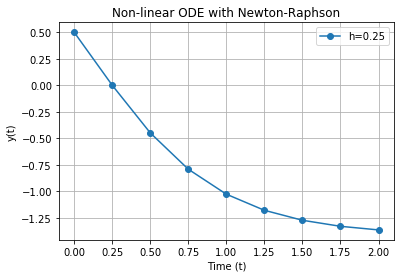

In [11]:
# Solve the nonlinear ODE
h = [0.01,0.05,0.1,0.15,0.2,0.25]
y0 = 0.5
t0 = 0
tf = 2

for i in range(len(h)):
    t_values_nl, y_values_nl = backward_euler_newton(f_nonlinear, y0, t0, tf, h[i])
    
    # Plot the results
    plt.plot(t_values_nl, y_values_nl, 'o-', label=f'h={h[i]}')
    plt.xlabel('Time (t)')
    plt.ylabel('y(t)')
    plt.title('Non-linear ODE with Newton-Raphson')
    plt.legend()
    plt.grid(True)
    plt.show()

The result here uses the derivative and maintains good accuracy for very small step sizes.